# Installing Packages

In [141]:
import numpy as np
import torch
import gc
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as tck
import time as timeit
import scipy as sp
# necessary for linear algebra
torch.backends.cuda.preferred_linalg_library("magma")
#from torchdiffeq import odeint

device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

Things to look at:
- https://jparkhill.netlify.app/solvingdiffusions/
- nangs for pytorch
- https://docs.pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html
- https://developer.nvidia.com/gpugems/gpugems2/part-vi-simulation-and-numerical-algorithms/chapter-44-gpu-framework-solving

In general, we want to solve the equation
$$\left(\frac{\hbar^2}{2m}\left( -i\nabla + \mathbf{k} \right)^2 + V(\mathbf{r})\right)u_k(\mathbf{r}) = E(k)u_k(\mathbf{r})$$
with periodic BCs $u_k(\mathbf{r} + \mathbf{R})$.

For simplicity, let's start with 1D only, then the requation reduces to
$$\left(\frac{\hbar^2}{2m}\left( -i\frac{\partial}{\partial x} + k \right)^2 + V(x)\right)u_k(x) = E(k)u_k(x)$$
with $u_k(x) = u_k(x + a)$ and $\Psi(x) = e^{ikx}u_k(x)$

# 1D Solver

If we expand and apply the derivatives, and set $\hbar = m = 1$ in the diffeq above, the equation has the form
$$-u'' + k^2u - 2iku' + 2(V(x) - E)u = 0$$
Now we convert this into a system of 2 first-order ODEs by setting ($u(x) = y(x) = y_0)$
$$y_0 = u$$
$$y_1 = \dot{y}_0 = u'$$
$$\dot{y}_1 = u''$$
Thus, we obtain the following differential equations:
$$\dot{y}_0 = y_1$$
$$\dot{y}_1 = -2iky_1 + (2(V(t) - E) + k^2)y_0$$
just by making the replacement $x\rightarrow t$ since the odesolver treats the independent variable as time.

We can write this as a homogeneous vector-valued differential equation, taking
$$\frac{d}{dt}\mathbf{y} = A\mathbf{y}$$
with $A$ as a matrix.

Note that the usual matrix exponential is not a valid solution for periodic systems. Instead, we can use the Floquet theorem^ to solve for the **fundamental matrix** $Y$ that satisfies the equation (which can be easily solved by taking the matrix exponential)
$$\frac{d}{dt}Y(t) = A(t)Y(t)$$
with
$$Y(t) = Q(t)e^{Bt}$$
$$Y(0) = I$$

By using the Lyapunov-Floquet Transformation $y = Q(t)q$ (introducing transformed coordinate q), we have
$$B = \frac{1}{T}ln(Y(T))$$
$$Q(t) = Y(t)e^{-Bt}$$
$$\dot{q} = Bq$$

Finally, with $Y(t)$ and $q(t)$ computed by their known solutions, and $Q(t)$ and $B$ computed by the known formulas, we can write down the solution for y(t), parametrized by $k$ and $E$.

The last step is to find the actual values of $E$ that obey the quantization condition, which we can do by noting that the trace of $Y(t)$ is invariant (is this actually true?), thus $\mathrm{Tr}(Y(t)) = \mathrm{Tr}(Y(0)) = 2$, leading to the function we will minimize with respect to $E$:
$$|\mathrm{Tr}(Y(t)) - 2|$$

But we'll have better-behaved results if we instead use the signed optimizing function
$$\ln\left(\frac{1}{2}\left\vert\mathrm{Tr}(Y(t))\right\vert\right)$$


^see https://www.12000.org/my_notes/liapunov_floquet_transformation/bMATH_2018_FolkersE.pdf

So far we have e.v.'s from $\det \left(\lambda - \left\vert \prod_{n = 1}^{N} A_{n}(E) \right\vert ^{1/N} \right) = 0$, ie $\lambda_{\pm}(E)$. Then, take the grid and define for every site a local derivative (another factor of 1024), i.e.

$$\alpha(E) = \frac{\vert\lambda_{\pm}(E +\epsilon) - \lambda_{\pm}(E)\vert}{\epsilon}$$

and look for the sign flips!

In [142]:
# everything is taking the form [[y_0(t)],
#                                [y_1(t)]]

"""Global Parameters"""

# initial conditions on u(0) and u'(0)
initial_conditions = torch.tensor([0, 1])

x_max = 10
# the code is not built to take negative x values, Y(x_min = 0) = I is forced
x_min = 0
x_steps = 1024
x_vals = torch.linspace(0, x_max, x_steps + 1, device = device)

period = x_max

params = {
    "x_max" : x_max,
    "x_min" : x_min,
    "x_vals" : x_vals,
    "x_steps" : x_steps,
    "T" : period,
    "y0" : initial_conditions
}

"""Defining Functions"""

def V(t):
    return (1/2) * (t - x_max / 2)**2

def A(t, k, E):
    a = torch.zeros(
        (2,2) + t.shape + E.shape, dtype = torch.complex64, device = device
    )
    a[0, 0] = 0
    a[0, 1] = 1
    a[1, 0] = 2 * (
        V(t).unsqueeze(-1).expand(t.shape + E.shape) - E.unsqueeze(0).expand(
            t.shape + E.shape
        )
    ) + k**2
    a[1, 1] = -2j * k
    return a.movedim((-2, -1), (0, 1))

def signChange(matrices):
    signed_matrices =  torch.sign(matrices)
    # takes adjacent elements and multiplies, if <= 0 then a sign change occured
    change_index = torch.argwhere(
        signed_matrices[:-1] * signed_matrices[1:] <= 0
    ).squeeze(dim = 1)
    return change_index

class LyapunovFloquetSolver:

    def __init__(self, k, params):
        self.k = k

        self.T = params["T"]

        self.x_max = params["x_max"]
        self.x_min = params["x_min"]
        self.x_steps = params["x_steps"]

        self.dx = (self.x_max + self.x_min) / (self.x_steps + 1)
        # throwing out first element correspoonding to Y(0) = I
        self.x_vals = params["x_vals"][1:]

    def construct_Y(self, E):
        if self.k == 0:
            a = (A(self.x_vals, self.k, E)).movedim((0, 1), (-2, -1))
            a_exp = torch.zeros(a.shape, dtype = torch.float64, device = device)
            m = torch.sqrt(a[1, 0])

            a_exp[0, 0] = torch.cosh(m * self.dx / self.x_steps)
            a_exp[1, 1] = torch.cosh(m * self.dx / self.x_steps)
            a_exp[1, 0] = torch.sinh(m * self.dx / self.x_steps) * m
            a_exp[0, 1] = torch.sinh(m * self.dx / self.x_steps) / m
            a_exp = torch.nan_to_num(torch.real(a_exp), nan = 1.0)

            a_exp = a_exp.movedim((0, 1), (-2, -1))
        else:
            a_exp = torch.matrix_exp(
                A(self.x_vals, self.k, E) * self.dx / self.x_steps
            )
        return a_exp

    def collapse_Y(self, E):
        matrices = self.construct_Y(E)
        while matrices.shape[0] > 1:
            # computer number of steps_per_t currently in unitaries
            n_slices = matrices.shape[0]

            # separate unitaries into pairs, view has dims [x_steps // 2, 2, E_steps, 2, 2]
            matrices = matrices.view((n_slices // 2, 2) + matrices.shape[1:])

            # multiply pairs until number of unitaries reduced below time_steps
            matrices = torch.matmul(matrices[:, 0], matrices[:, 1])
        return matrices.squeeze()

    def loss(self, E):
        #TODO: REMOVE THIS
        E = torch.tensor([E], device=device)
        matrices = self.collapse_Y(E)
        evals = torch.linalg.eigvals(matrices)
        # print(evals)
        # print(torch.max(torch.abs(evals), dim = 1))  # fix this !!!
        log_evals = (
            -1/torch.log(torch.max(torch.abs(evals)) - 1)
        )
        #trace = matrices[:, 0, 0] + matrices[:, 1, 1]
        #return torch.log(torch.abs(trace/2))
        return torch.nan_to_num(log_evals).item()

    def coarseGrain(self, E):
        loss_array = self.loss(E) # generate the first loss array
        change_index = signChange(loss_array)
        change_list = change_index.tolist()
        return E[change_list], loss_array[change_list], change_index

    def optimize(self, losstol = 0.1):
        # pulling x_vals from outside class to keep first element (could be min/max)
        E_max, E_min = (V(x_vals).max(), V(x_vals).min()) 
        E_steps = 1024
        E_grid = torch.linspace(
            E_min, E_max, E_steps, dtype = torch.float64, device = device
        )

        change_energies, loss, change_index = self.coarseGrain(E_grid)

        print("Initial E_grid =", E_grid)
        print("Initial change_energies =", change_energies)
        print("Initial loss =", loss)
        print("Initial change_index =", change_index)

        while not(torch.all(loss <= losstol)):
            idx_to_eval = torch.argwhere(
                torch.abs(loss) > losstol
            ).squeeze(dim = 1).tolist()
            print("idx_to_eval =", idx_to_eval)
            E_list = []
            change_list = []
            for i in range(len(idx_to_eval)):
                E_idx = change_index[idx_to_eval[i]]
                loop_E_grid = torch.linspace(
                    E_grid[E_idx],
                    E_grid[E_idx + 1],
                    E_steps,
                    dtype = torch.float64,
                    device = device
                )
                (
                    loop_change_energies,
                    loop_loss,
                    loop_change_index
                ) = self.coarseGrain(loop_E_grid)

                print("\nStart of iteration", str(i))
                print("loop_E_grid =", loop_E_grid)
                print("loop_change_energies =", loop_change_energies)
                print("loop_loss =", loop_loss)
                print("loop_change_index =", loop_change_index)
                print("End of iteration", str(i), "\n")

                change_energies = torch.cat(
                    (
                        change_energies[:idx_to_eval[i]],
                        loop_change_energies,
                        change_energies[idx_to_eval[i] + 1:]
                    )
                )
                loss = torch.cat(
                    (
                        loss[:idx_to_eval[i]],
                        loop_loss, loss[idx_to_eval[i] + 1:]
                    )
                )

                E_list.append(loop_E_grid)
                change_list.append(loop_change_index + i*E_steps)

            E_grid = torch.cat(E_list)
            change_index = torch.cat(change_list)

        print("E_grid =", E_grid)
        print("change_energies =", change_energies)
        print("loss =", loss)
        print("change_index =", change_index)

        print("Energy Check:", E_grid[change_index.tolist()])

        return change_energies

In [143]:
test = LyapunovFloquetSolver(0, params)

In [151]:
test.loss(4.165)

0.13336454642328416

In [146]:
sp.optimize.newton(test.loss, 0, maxiter=10)

RuntimeError: Failed to converge after 10 iterations, value is 262.31329119631897.

NameError: name 'results' is not defined

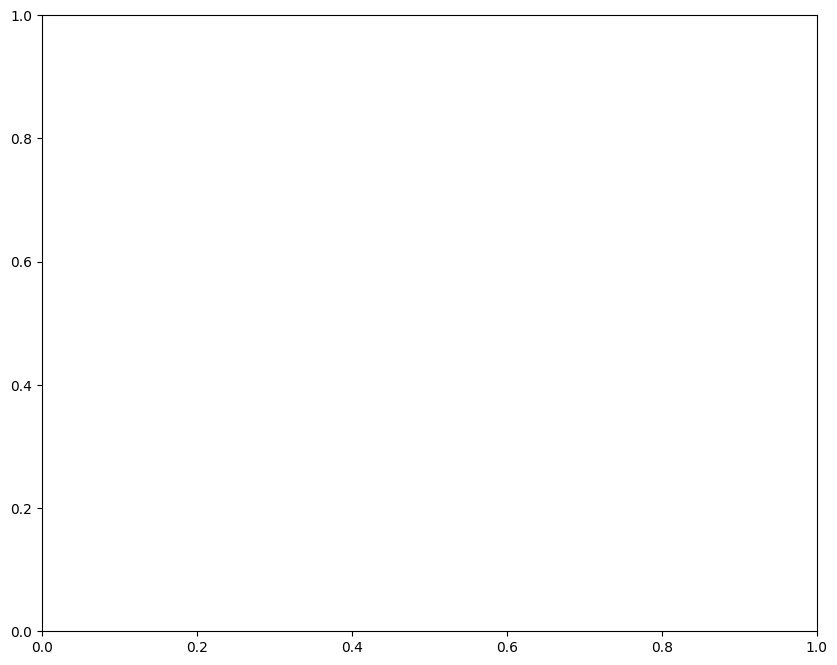

In [ ]:
fig, ax = plt.subplots(figsize = (10, 8))

ax.plot(results.x, np.abs(results.y[0])**2, label = r"$|u_k(x)|^2$")

ax.legend()
ax.grid()
ax.set_title(r"$|u_k(x)|^2$ Plot in Single Unit Cell")

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$|u_k(x)|^2$")

plt.show()

In [ ]:
"""%%time

initial_conditions = np.array([0, 1], dtype = np.complex64)

def ode(t, y):

  ode_array = np.array([[0, 1],
                        [2*(V(t) - E) + k**2, -2j*k]]).transpose() #transposed b/c scipy treats as row vectors

  return (y @ ode_array)

def odeTorch(t, y):

  ode_array = torch.tensor([[0, 1],
                        [2*(V(t) - E) + k**2, -2j*k]], device = device, dtype = torch.complex64).transpose() #transposed b/c scipy treats as row vectors

  return torch.matmul((y, ode_array), device = device, dtype = torch.complex64)

def fun(x, y, p):
  E = p[0]
  return np.vstack((y[1], -1j * k * y[1] + 2 * ((V(x) - E) + k**2) * y[0]))

def bc(ya, yb, p):
  E = p[0]
  return np.array([ya[0] - yb[0], ya[1] - yb[1], ya[0] - E])

x_vals = np.linspace(0, x_max, x_steps)


#results = sp.integrate.solve_ivp(ode, (0, x_max), initial_conditions, t_eval = x_vals, vectorized = False)
results = sp.integrate.solve_bvp(fun, bc, x_vals, np.vstack((np.cos(x_vals, dtype = np.complex64), np.sin(x_vals, dtype = np.complex64))), [0.5])
#results_pytorch = odeint(odeTorch, initial_conditions_tensor, x_vals_tensor)"""